In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [131]:
#3
df = pd.DataFrame(pd.read_csv("../../course_assignments/homework9/solar_system.csv"))

In [132]:
#4
print(df.shape)
#there are 20 rows and 11 columns

print(df.head())
print(df.tail())

print(df.columns)
print(df["Attribute"])

(20, 11)
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring Sy

In [133]:
#5
orbital_period = df.iloc[10,1:].astype(float)

perihelion = df.iloc[8,1:].astype(float)

aphelion = df.iloc[9,1:].astype(float)

In [134]:
#6
#Perihelion: The Point on a planet's orbit in which it is closest to the sun
#Aphelion: the point on a planet's orbit in which it is furthest from the sun
#Semi-Major Axis: One half of the larger diameter of a planet's elliptical orbit.

In [135]:
#7
semi_major_axis = (perihelion + aphelion)/2

In [136]:
#8
series = pd.Series(semi_major_axis)
df = pd.concat([df, series.to_frame().T], ignore_index = True)
df.loc[20, "Attribute"] = "Semi Major Axis (10^6 km)"

In [137]:
#9
df.shape
#There are 21 rows and 11 columns

(21, 11)

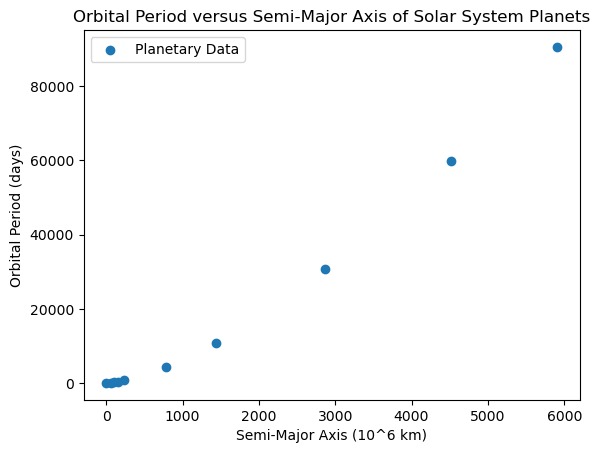

In [138]:
#10
#the keplers third law we use in the next problem is predicting period from semi major axis, so I put the variables in that order
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label = "Planetary Data")
plt.title("Orbital Period versus Semi-Major Axis of Solar System Planets")
plt.xlabel("Semi-Major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.legend()
plt.show()

In [109]:
#11
def keplers_third_law(a,m):
    return m*a**1.5

In [112]:
#12
p0 = [1]
popt,pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)

In [113]:
#13
m_fit = popt[0]
print(m_fit)

0.1987998191813986


In [141]:
#14
print(f"Fit: y = {m_fit:.2f}*a^1.5")

Fit: y = 0.20*a^1.5


In [120]:
#15
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2= np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2/dof

print(chi2_reduced)

41276.70608939304


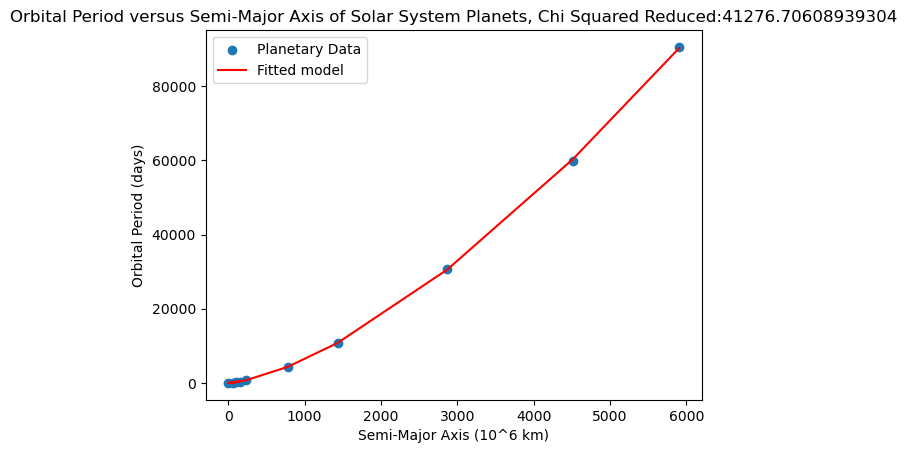

In [139]:
#16
plt.figure()
plt.scatter(semi_major_axis, orbital_period, label = "Planetary Data")
plt.plot(semi_major_axis,keplers_third_law(semi_major_axis, m_fit), label = "Fitted model", color = "red")
plt.title(f"Orbital Period versus Semi-Major Axis of Solar System Planets, Chi Squared Reduced:{chi2_reduced}")
plt.xlabel("Semi-Major Axis (10^6 km)")
plt.ylabel("Orbital Period (days)")
plt.legend()
plt.show()

In [140]:
#17
df.to_csv("kepler.csv", index = False)